# Chapter 48 — Uncertainty Propagation
### *Modern Strain Gage Technology* — Companion Notebook

Companion notebook to Chapter 48 — Uncertainty Propagation.

When Lord Kelvin propagated the uncertainty in his cooling model to date the Earth, the arithmetic was impeccable and the answer was wrong by nearly a hundredfold — a standing reminder that propagation tells you how uncertain a result is *given that the model is right*, never whether the model itself is right. This notebook stays on the honest side of that line: it takes a model we trust and asks how the uncertainties of its inputs combine into the uncertainty of its output.

Propagating uncertainty through a measurement model means converting the uncertainties of the input quantities into the uncertainty of the output quantity. The **GUM analytical method** does this by linearizing the measurement function: each input uncertainty *u(xᵢ)* is multiplied by the corresponding **sensitivity coefficient** *cᵢ = ∂f/∂xᵢ*, and the weighted contributions are combined in quadrature. For measurement functions that are nearly linear over the range of interest, the analytical method is accurate and efficient.

When the measurement function is significantly nonlinear — or when the input distributions are not well-described by standard forms — the **Monte Carlo method** (Supplement 1 to the GUM) provides a more rigorous alternative. Random samples are drawn from each input distribution, the measurement function is evaluated for each sample set, and the distribution of the output is computed from the ensemble. The standard uncertainty is simply the standard deviation of the output samples; confidence intervals can be read directly from the empirical distribution without assuming normality.

The quarter-bridge strain formula *ε = 4 V_out / (V_ex · GF)* is nearly linear in *V_out* but slightly nonlinear in *GF* and *V_ex* because they appear in the denominator. For the uncertainties typical in strain measurement, the GUM and Monte Carlo methods agree on the standard uncertainty to within a fraction of a percent, although, as section 1 shows, they need not agree on the shape of the distribution. This notebook demonstrates both approaches on the same measurement to show the agreement and illustrate when the more rigorous Monte Carlo method is warranted.

**This notebook demonstrates:**
1. Monte Carlo uncertainty propagation (N = 100,000 trials) for the quarter-bridge strain measurement of Eq. 48.5, checked against the GUM analytical result (Figure 48.1).
2. A case where the two methods part company: principal and maximum shear stress from a rosette near an equibiaxial state (Figure 48.2).

In [1]:
# !pip install numpy matplotlib scipy
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 12})

# Figures are written next to the book's Chapter 48 source so the build picks them up.
OUT_DIR = Path("../src/media/ch48")
OUT_DIR.mkdir(parents=True, exist_ok=True)

---
## 1 — GUM Analytical vs. Monte Carlo Propagation (Figure 48.1)

The simulation below uses exactly the inputs of the chapter's worked example, Eq. 48.5, and draws N = 100,000 samples from the distribution of each:

| Input | Nominal | Stated as | Distribution | Fractional standard uncertainty |
|---|---|---|---|---|
| Gage factor *GF* | 2.07 | ±0.5 % on the package, no *k* | rectangular | 0.005/√3 = 0.00289 |
| Bridge output *V_out* | (from 1,000 με) | 0.05 % at *k* = 1 | normal | 0.0005 |
| Excitation *V_ex* | 5.000 V | 0.01 % at *k* = 1 | normal | 0.0001 |

It evaluates *ε = 4 V_out / (V_ex · GF)* for each sample set and compares the result with the GUM analytical value of Eq. 48.5, *u_c/ε* = 0.293 %, or 2.93 με at 1,000 με.

The two standard uncertainties agree closely. The *shapes* do not. The rectangular gage-factor term carries 97 % of the variance, so the output inherits its flat-topped shape (Chapter 45 warns of exactly this when one contributor dominates). The 95 % interval read from the Monte Carlo percentiles is therefore noticeably narrower than the GUM's symmetric ±2*u_c*: a rectangular distribution has no tails, and ±2σ reaches beyond its edges.

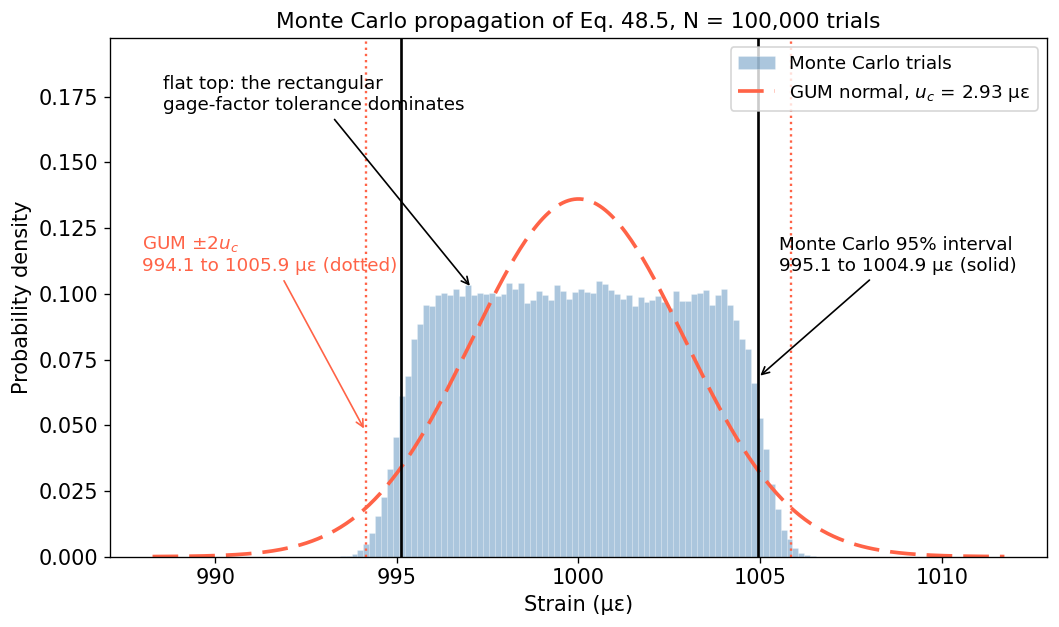

Monte Carlo: u_c = 2.932 με, mean 1000.01 με (N=100,000)
GUM method:  u_c = 2.931 με  (0.293 %)
Agreement of u_c: 0.02%
95% interval  MC: 995.12 to 1004.94 με (half-width 4.91)
95% interval GUM: 994.14 to 1005.86 με (half-width 5.86)
Coverage of GUM +/-2u_c in the MC sample: 99.80%


In [2]:
# Monte Carlo uncertainty propagation for a quarter-bridge strain measurement.
# Model (Chapter 48, Eq. 48.3):  epsilon = 4 * Vout / (Vex * GF) * 1e6   [microstrain]
# Inputs: the worked example of Eq. 48.5.

N_TRIALS      = 100_000   # number of Monte Carlo trials
STRAIN_NOM_UE = 1000.0    # nominal indicated strain, microstrain
RANDOM_SEED   = 0         # fix the RNG so the saved figure is reproducible

GF_NOM       = 2.07       # gage factor, nominal
GF_TOL_FRAC  = 0.005      # package tolerance +/-0.5%, no coverage factor -> rectangular
VEX_NOM_V    = 5.00       # bridge excitation voltage, V
VEX_REL_STD  = 0.0001     # excitation standard uncertainty, fractional (0.01%, k = 1)
VOUT_REL_STD = 0.0005     # bridge-output standard uncertainty, fractional (0.05%, k = 1)

# Bridge output that produces STRAIN_NOM_UE at the nominal gage factor and excitation.
VOUT_NOM_V = VEX_NOM_V * GF_NOM * (STRAIN_NOM_UE * 1e-6) / 4.0


def quarter_bridge_strain(vout, vex, gf):
    # Indicated strain in microstrain from a quarter bridge (Eq. 48.3).
    return 4.0 * vout / (vex * gf) * 1e6


rng = np.random.default_rng(RANDOM_SEED)
GF_mc   = rng.uniform(GF_NOM * (1 - GF_TOL_FRAC), GF_NOM * (1 + GF_TOL_FRAC), N_TRIALS)
Vex_mc  = rng.normal(VEX_NOM_V,  VEX_NOM_V * VEX_REL_STD,   N_TRIALS)
Vout_mc = rng.normal(VOUT_NOM_V, VOUT_NOM_V * VOUT_REL_STD, N_TRIALS)
eps_mc  = quarter_bridge_strain(Vout_mc, Vex_mc, GF_mc)

mu, sigma = eps_mc.mean(), eps_mc.std()
lo, hi = np.percentile(eps_mc, [2.5, 97.5])

# GUM analytical result (Eq. 48.4/48.5): fractional uncertainties in quadrature.
u_rel_GUM = np.sqrt((GF_TOL_FRAC / np.sqrt(3))**2 + VOUT_REL_STD**2 + VEX_REL_STD**2)
u_GUM = STRAIN_NOM_UE * u_rel_GUM

plt.rcParams.update({'font.size': 12.5, 'axes.titlesize': 13})
fig, ax = plt.subplots(figsize=(9, 5.4))
ax.hist(eps_mc, bins=80, color='steelblue', alpha=0.45, edgecolor='white',
        linewidth=0.3, density=True, label='Monte Carlo trials')
x = np.linspace(STRAIN_NOM_UE - 4 * u_GUM, STRAIN_NOM_UE + 4 * u_GUM, 300)
ax.plot(x, norm.pdf(x, STRAIN_NOM_UE, u_GUM), color='tomato', lw=2.2,
        linestyle=(0, (7, 3)), label=f'GUM normal, $u_c$ = {u_GUM:.2f} με')
# 95% intervals: Monte Carlo percentiles (solid) vs GUM +/-2u_c (dotted)
for v in (lo, hi):
    ax.axvline(v, color='black', lw=1.6, linestyle='-')
for v in (STRAIN_NOM_UE - 2 * u_GUM, STRAIN_NOM_UE + 2 * u_GUM):
    ax.axvline(v, color='tomato', lw=1.4, linestyle=':')
ymax = norm.pdf(STRAIN_NOM_UE, STRAIN_NOM_UE, u_GUM)
ax.annotate(f'Monte Carlo 95% interval\n{lo:.1f} to {hi:.1f} με (solid)',
            xy=(hi, ymax * 0.5), xytext=(hi + 0.2 * u_GUM, ymax * 0.8), fontsize=11,
            arrowprops=dict(arrowstyle='->', lw=1.0))
ax.annotate(f'GUM ±2$u_c$\n{STRAIN_NOM_UE - 2*u_GUM:.1f} to {STRAIN_NOM_UE + 2*u_GUM:.1f} με (dotted)',
            xy=(STRAIN_NOM_UE - 2 * u_GUM, ymax * 0.35), xytext=(STRAIN_NOM_UE - 4.1 * u_GUM, ymax * 0.80),
            fontsize=11, color='tomato', arrowprops=dict(arrowstyle='->', color='tomato', lw=1.0))
ax.annotate('flat top: the rectangular\ngage-factor tolerance dominates',
            xy=(STRAIN_NOM_UE - 1.0 * u_GUM, ymax * 0.75), xytext=(STRAIN_NOM_UE - 3.9 * u_GUM, ymax * 1.25),
            fontsize=11, arrowprops=dict(arrowstyle='->', lw=1.0))
ax.set_ylim(0, ymax * 1.45)
ax.set_xlabel('Strain (με)')
ax.set_ylabel('Probability density')
ax.set_title(f'Monte Carlo propagation of Eq. 48.5, N = {N_TRIALS:,} trials')
ax.legend(fontsize=11, loc='upper right')
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig48_nb1_uncertainty_monte_carlo.png', bbox_inches='tight', dpi=300)
plt.show()

print(f"Monte Carlo: u_c = {sigma:.3f} με, mean {mu:.2f} με (N={N_TRIALS:,})")
print(f"GUM method:  u_c = {u_GUM:.3f} με  ({u_rel_GUM*100:.3f} %)")
print(f"Agreement of u_c: {abs(sigma - u_GUM) / u_GUM * 100:.2f}%")
print(f"95% interval  MC: {lo:.2f} to {hi:.2f} με (half-width {(hi-lo)/2:.2f})")
print(f"95% interval GUM: {STRAIN_NOM_UE-2*u_GUM:.2f} to {STRAIN_NOM_UE+2*u_GUM:.2f} με (half-width {2*u_GUM:.2f})")
print(f"Coverage of GUM +/-2u_c in the MC sample: {np.mean(np.abs(eps_mc-STRAIN_NOM_UE) <= 2*u_GUM)*100:.2f}%")

---
## 2 — Where GUM and Monte Carlo part company: a near-equibiaxial rosette (Figure 48.2)

A rectangular rosette reads ε_A = ε_C = 500 με and ε_B = 510 με on steel (*E* = 200 GPa, ν = 0.29). The stress state is nearly equibiaxial: the radius of Mohr's stress circle, which is the maximum in-plane shear stress τ_max, is only 1.55 MPa, while each strain channel carries the 4.85 με standard uncertainty of the Chapter 45 budget (taken here as independent and normal, as in Table 48.1; *E* and ν carry their Table 48.1 uncertainties).

The radius is a square root of a sum of squares, so it can never be negative. With a true value only about 1.7 times its own GUM standard uncertainty, the GUM's linearized normal distribution puts a visible share of its probability below zero, and its symmetric interval runs to an impossible negative shear stress. The Monte Carlo distribution is bounded at zero, skewed to the right, and centred above the nominal value. The maximum principal stress σ₁ inherits that skew only weakly, because its uncertainty is dominated by the mean-stress term (ε_A + ε_C), which is linear.

$\tau_{max}$: nominal 1.550, GUM u 0.921 | MC mean 1.695, sd 0.811, 95% [0.320, 3.393], skewness +0.371
$\sigma_1$: nominal 142.395, GUM u 1.226 | MC mean 142.539, sd 1.215, 95% [140.176, 144.935], skewness +0.028
GUM probability of tau_max < 0: 4.6%


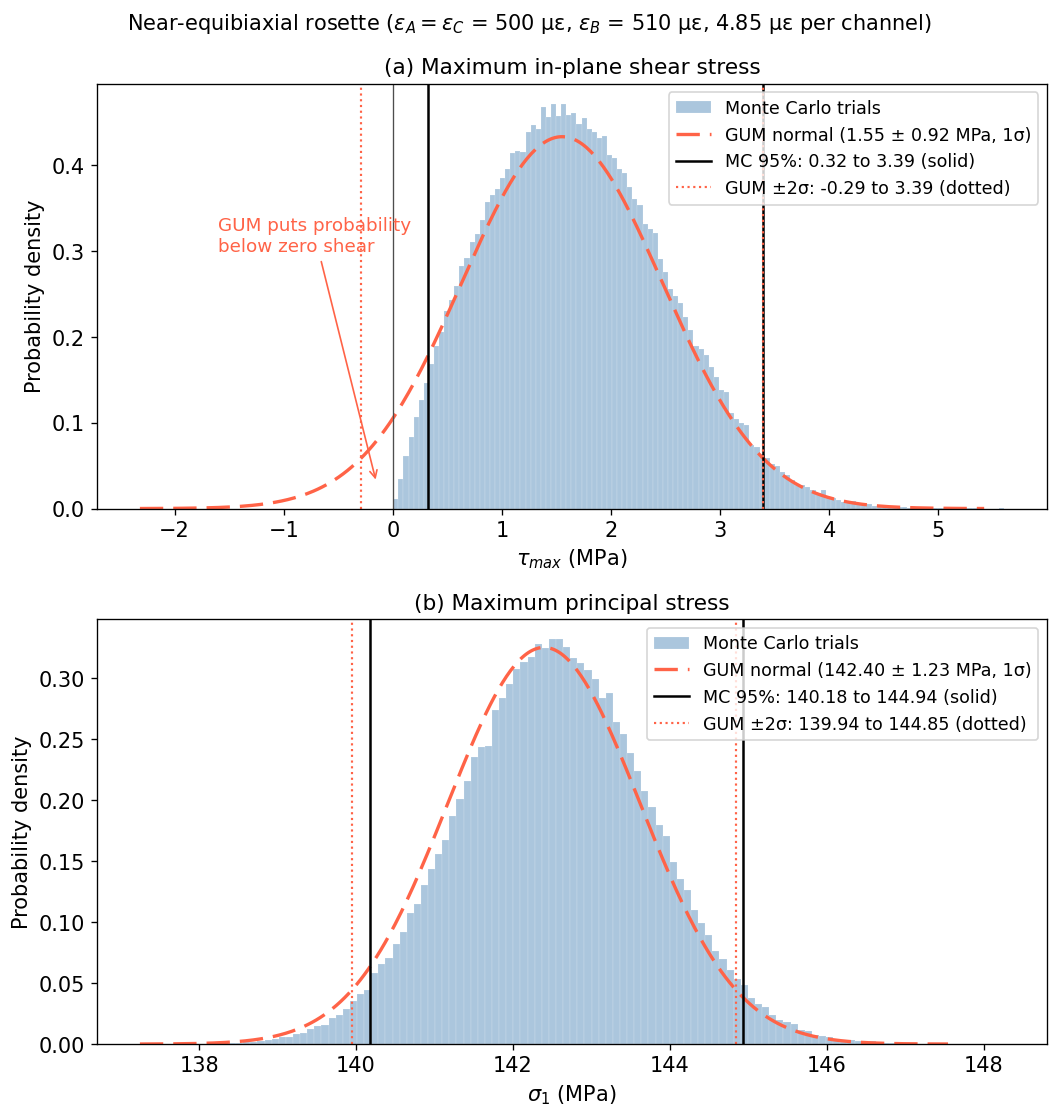

In [3]:
# Near-equibiaxial rosette: GUM vs Monte Carlo for tau_max and sigma_1 (Eq. 48.7)
from scipy.stats import skew

E_GPA, U_E_GPA = 200.0, 1.0      # Young's modulus and its standard uncertainty (Table 48.1)
NU, U_NU       = 0.29, 0.0025    # Poisson's ratio and its standard uncertainty (Table 48.1)
U_EPS          = 4.85            # per-channel standard uncertainty, με (Chapter 45 budget)
EPS_NOM = dict(eA=500.0, eB=510.0, eC=500.0)
N_ROS = 200_000


def rosette_stresses(eA, eB, eC, E_gpa, nu):
    # Principal stresses and max in-plane shear (MPa) from a rectangular rosette, Eq. 48.7.
    mean = E_gpa * 1e3 / (2 * (1 - nu)) * (eA + eC) * 1e-6
    rad = E_gpa * 1e3 / (2 * (1 + nu)) * np.sqrt((eA - eC)**2 + (2*eB - eA - eC)**2) * 1e-6
    return mean + rad, mean - rad, rad


def gum_u(fun_index):
    # First-order (GUM) standard uncertainty by central differences (Eq. 48.6).
    x0 = dict(EPS_NOM, E_gpa=E_GPA, nu=NU)
    u = dict(eA=U_EPS, eB=U_EPS, eC=U_EPS, E_gpa=U_E_GPA, nu=U_NU)
    tot = 0.0
    for k in x0:
        d = 1e-4 * max(abs(x0[k]), 1.0)
        xp, xm = dict(x0), dict(x0)
        xp[k] += d; xm[k] -= d
        c = (rosette_stresses(**xp)[fun_index] - rosette_stresses(**xm)[fun_index]) / (2 * d)
        tot += (c * u[k])**2
    return rosette_stresses(**x0)[fun_index], np.sqrt(tot)


rng2 = np.random.default_rng(48)
eA = rng2.normal(EPS_NOM['eA'], U_EPS, N_ROS)
eB = rng2.normal(EPS_NOM['eB'], U_EPS, N_ROS)
eC = rng2.normal(EPS_NOM['eC'], U_EPS, N_ROS)
Em = rng2.normal(E_GPA, U_E_GPA, N_ROS)
nm = rng2.normal(NU, U_NU, N_ROS)
s1_mc, s2_mc, tau_mc = rosette_stresses(eA, eB, eC, Em, nm)

plt.rcParams.update({'font.size': 12.5, 'axes.titlesize': 13})
fig, axes = plt.subplots(2, 1, figsize=(9, 9.5))
for ax, arr, idx, name, unit_lab in ((axes[0], tau_mc, 2, r'$\tau_{max}$', '(a) Maximum in-plane shear stress'),
                                     (axes[1], s1_mc, 0, r'$\sigma_1$', '(b) Maximum principal stress')):
    nom, ug = gum_u(idx)
    lo, hi = np.percentile(arr, [2.5, 97.5])
    ax.hist(arr, bins=120, density=True, color='steelblue', alpha=0.45, edgecolor='white',
            linewidth=0.2, label='Monte Carlo trials')
    x = np.linspace(nom - 4.2 * ug, nom + 4.2 * ug, 400)
    ax.plot(x, norm.pdf(x, nom, ug), color='tomato', lw=2.0, linestyle=(0, (7, 3)),
            label=f'GUM normal ({nom:.2f} ± {ug:.2f} MPa, 1σ)')
    ax.axvline(lo, color='black', lw=1.5); ax.axvline(hi, color='black', lw=1.5,
               label=f'MC 95%: {lo:.2f} to {hi:.2f} (solid)')
    ax.axvline(nom - 2 * ug, color='tomato', lw=1.3, linestyle=':')
    ax.axvline(nom + 2 * ug, color='tomato', lw=1.3, linestyle=':',
               label=f'GUM ±2σ: {nom-2*ug:.2f} to {nom+2*ug:.2f} (dotted)')
    ax.set_title(unit_lab)
    ax.set_xlabel(f'{name} (MPa)')
    ax.set_ylabel('Probability density')
    ax.legend(fontsize=10.5, loc='upper right')
    print(f"{name}: nominal {nom:.3f}, GUM u {ug:.3f} | MC mean {arr.mean():.3f}, sd {arr.std():.3f}, "
          f"95% [{lo:.3f}, {hi:.3f}], skewness {skew(arr):+.3f}")
axes[0].axvline(0, color='0.3', lw=0.8)
axes[0].annotate('GUM puts probability\nbelow zero shear', xy=(-0.15, 0.03), xytext=(-1.6, 0.30),
                 fontsize=11, color='tomato', arrowprops=dict(arrowstyle='->', color='tomato', lw=1.0))
nom_tau, u_tau = gum_u(2)
print(f"GUM probability of tau_max < 0: {norm.cdf(0, nom_tau, u_tau)*100:.1f}%")
fig.suptitle(r'Near-equibiaxial rosette ($\varepsilon_A = \varepsilon_C$ = 500 με, $\varepsilon_B$ = 510 με, 4.85 με per channel)', fontsize=12.5)
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig48_nb2_rosette_equibiaxial.png', bbox_inches='tight', dpi=300)
plt.show()

---
## Where to take this next

This notebook covers the multiplicative strain model and one nonlinear rosette case. The chapter develops further cases that are worth building here:

1. **Reproduce the rosette stress budget (Table 48.1).** Implement the principal-stress formula (Eq. 48.7) for a rectangular 0°/45°/90° rosette, compute the five sensitivity coefficients by central difference (Eq. 48.6), and assemble the *cᵢ · uᵢ* budget. Confirm that Young's modulus *E*, not the strain channels, dominates the combined uncertainty.
2. **Share the calibration.** Rerun section 2 with part of each channel's 4.85 με moved into a component common to all three channels (a shared thermal offset, say). A common offset cancels in the radius of Mohr's circle, so τ_max tightens while σ₁ and σ₂ widen together.
3. **Add correlated inputs (Eq. 48.8).** Split each rosette channel's uncertainty into a shared-calibration component and an independent component, then show how positive correlation among the three channels changes the combined stress uncertainty relative to the naive root-sum-of-squares — sometimes larger, sometimes smaller, depending on how the sensitivity coefficients add.